In [4]:
from sklearn.base import BaseEstimator
import numpy as np
import pandas as pd

# 분류기 1
class MyDummyClassfier(BaseEstimator):
    def fit(self, X, y= None):
        pass

    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]): # sex == 1이면 survived = 0으로 예측, 아니면 1로 예측
            if X['Sex'].iloc[i] == 1:
                pred[i] = 0
            else : 
                pred[i] = 1
        return pred

In [5]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# data load
titanic_df = pd.read_csv(r'C:\Users\KDW\py_ml_env\data\Titanic-Dataset.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

# 전처리
X_titanic_df = transform_features(X_titanic_df)
# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=0)

C:\Users\KDW\AppData\Local\Temp\ipykernel_30272\340051843.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\KDW\AppData\Local\Temp\ipykernel_30272\340051843.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [12]:

# 모델 생성
myclf = MyDummyClassfier()
myclf.fit(X_train, y_train)

In [14]:
my_pred = myclf.predict(X_test)
accuracy_score(y_test, my_pred)

0.7877094972067039

# 오차행렬

In [17]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, my_pred) # row : 실제값, col : 예측값

array([[92, 18],
       [20, 49]])

In [18]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_test, my_pred), recall_score(y_test, my_pred)

(0.7313432835820896, 0.7101449275362319)

In [15]:
# MNIST DATASET - 손글씨 데이터 셋
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [ ]:
# 149page의 MyFakeClassifier를 이용한 정확도 측정

In [19]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [20]:
X_titanic_df.head(), y_titanic_df.head()

(   Pclass  Sex   Age  SibSp  Parch     Fare  Cabin  Embarked
 0       3    1  22.0      1      0   7.2500      7         3
 1       1    0  38.0      1      0  71.2833      2         0
 2       3    0  26.0      0      0   7.9250      7         3
 3       1    0  35.0      1      0  53.1000      2         3
 4       3    1  35.0      0      0   8.0500      7         3,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: Survived, dtype: int64)

In [30]:
# X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

In [31]:
# p156
def get_clf_eval(y_test, pred):
    pass

In [33]:
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)

    print(confusion)
    print('*'*20)
    print(accuracy, precision, recall)

In [34]:
# 로지스틱회귀 분류모델 생성
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

# 정확도, 정밀도, 재현율
get_clf_eval(y_test, pred)

[[104  14]
 [ 13  48]]
********************
0.8491620111731844 0.7741935483870968 0.7868852459016393


c:\Users\KDW\.conda\envs\ml_env\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
lr_clf.predict_proba(X_test)

array([[0.46185748, 0.53814252],
       [0.87867005, 0.12132995],
       [0.87716667, 0.12283333],
       [0.88265168, 0.11734832],
       [0.85511781, 0.14488219],
       [0.88225492, 0.11774508],
       [0.88842072, 0.11157928],
       [0.20875208, 0.79124792],
       [0.7827161 , 0.2172839 ],
       [0.36954029, 0.63045971],
       [0.89982915, 0.10017085],
       [0.87492758, 0.12507242],
       [0.87716068, 0.12283932],
       [0.88837474, 0.11162526],
       [0.43646944, 0.56353056],
       [0.85895827, 0.14104173],
       [0.9036873 , 0.0963127 ],
       [0.7333301 , 0.2666699 ],
       [0.72464827, 0.27535173],
       [0.17177972, 0.82822028],
       [0.75352602, 0.24647398],
       [0.61908396, 0.38091604],
       [0.85459213, 0.14540787],
       [0.81471154, 0.18528846],
       [0.88800342, 0.11199658],
       [0.76544456, 0.23455544],
       [0.85966954, 0.14033046],
       [0.92588022, 0.07411978],
       [0.71949043, 0.28050957],
       [0.69535624, 0.30464376],
       [0.

In [36]:
# 이진화 
pred_proba = lr_clf.predict_proba(X_test)
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1,1)], axis=1)
pred_proba_result

array([[0.46185748, 0.53814252, 1.        ],
       [0.87867005, 0.12132995, 0.        ],
       [0.87716667, 0.12283333, 0.        ],
       [0.88265168, 0.11734832, 0.        ],
       [0.85511781, 0.14488219, 0.        ],
       [0.88225492, 0.11774508, 0.        ],
       [0.88842072, 0.11157928, 0.        ],
       [0.20875208, 0.79124792, 1.        ],
       [0.7827161 , 0.2172839 , 0.        ],
       [0.36954029, 0.63045971, 1.        ],
       [0.89982915, 0.10017085, 0.        ],
       [0.87492758, 0.12507242, 0.        ],
       [0.87716068, 0.12283932, 0.        ],
       [0.88837474, 0.11162526, 0.        ],
       [0.43646944, 0.56353056, 1.        ],
       [0.85895827, 0.14104173, 0.        ],
       [0.9036873 , 0.0963127 , 0.        ],
       [0.7333301 , 0.2666699 , 0.        ],
       [0.72464827, 0.27535173, 0.        ],
       [0.17177972, 0.82822028, 1.        ],
       [0.75352602, 0.24647398, 0.        ],
       [0.61908396, 0.38091604, 0.        ],
       [0.

In [37]:
# 이진화화
custom_threshold = 0.4
pred_proba_1 = pred_proba[:, 1].reshape(-1,1)# 새로운 예측값

# 정밀도, 재현율의 변화

In [40]:
from sklearn.preprocessing import Binarizer
binarizer = Binarizer(threshold= custom_threshold).fit(pred_proba_1)# 새로운 예측값으로 이진화한 예측값
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

[[98 20]
 [10 51]]
********************
0.8324022346368715 0.7183098591549296 0.8360655737704918


In [ ]:
# [[104  14]
# [ 13  48]]
# ********************
# 0.8491620111731844 0.7741935483870968 0.7868852459016393

# f1-score

In [41]:
from sklearn.metrics import f1_score
f1_score(y_test, pred)

0.7804878048780488

# ROC(Receiver Operation Charactertistics)
민감도 어떻게 달라지는지 보는 지표(=재현율, 실제 양성을 나타낸 비율)
거짓긍정율 = 1-특이도<br>

In [43]:
# ROC(Receiver Operation Charactertistics)
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]
pred_proba_class1

array([0.53814252, 0.12132995, 0.12283333, 0.11734832, 0.14488219,
       0.11774508, 0.11157928, 0.79124792, 0.2172839 , 0.63045971,
       0.10017085, 0.12507242, 0.12283932, 0.11162526, 0.56353056,
       0.14104173, 0.0963127 , 0.2666699 , 0.27535173, 0.82822028,
       0.24647398, 0.38091604, 0.14540787, 0.18528846, 0.11199658,
       0.23455544, 0.14033046, 0.07411978, 0.28050957, 0.30464376,
       0.94727855, 0.81731416, 0.12693095, 0.82611763, 0.39958997,
       0.23455544, 0.07238643, 0.61115551, 0.05297014, 0.10391268,
       0.35090454, 0.08333228, 0.82176313, 0.70789294, 0.63042367,
       0.63043998, 0.91882999, 0.35826298, 0.94891776, 0.11203117,
       0.59290812, 0.11162526, 0.13280787, 0.72549529, 0.30946165,
       0.19685782, 0.22626864, 0.12283438, 0.1542376 , 0.43251721,
       0.28021718, 0.10080806, 0.54558072, 0.51421146, 0.44428341,
       0.09458908, 0.66678417, 0.59406169, 0.9518255 , 0.14816854,
       0.12896962, 0.16849367, 0.10391493, 0.94801441, 0.19866

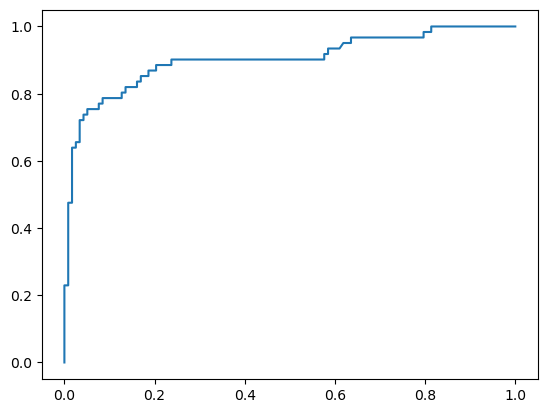

In [44]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fprs,tprs,thresholds = roc_curve(y_test, pred_proba_class1)

# 시각화
plt.plot(fprs, tprs, label='ROC')
plt.show()


In [45]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, pred_proba_class1)

np.float64(0.9024034454015005)

모델1의 ROC-AUC = 0.92 - 모델의 판별 성능이 우수 <BR>
모델2의 ROC-AUC = 0.78 - 모델1보다 성능이 낮다.